# 🏍️ **Pandas + Seaborn Practice — Bike Resale Listings**

A website sells used bikes. The owner needs answers from the listings.

Solve each question in the empty cell below it.

---



# ⚙️ **0. Setup**

### _Run this cell first — it loads the dataset used throughout the notebook._

---



In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/ankit/BOX 1/B1 ROOM 1/AI&ML/class15/bike_resale.csv')
df.head()



,bike_id,brand,age_months,km_driven,owner_count,condition,mileage_kmpl,service_count,insurance,price_thousand,sold_in_week
0,B4543,TVS,25,14455.0,3,Excellent,40.6,NaN,Yes,41.6,No
1,B4392,TVS,43,26304.0,2,Good,51.2,1.0,Yes,24.1,No
2,B4235,Honda,38,6421.0,1,Good,65.0,NaN,No,48.2,No
3,B4319,Hero,14,6531.0,1,Good,NaN,NaN,Yes,58.7,No
4,B4284,TVS,115,80000.0,1,Good,61.8,0.0,No,12.0,Yes


# 🎯 **1. Selecting Data**

### _`df[['a','b']]` → select specific columns | `df[df['col'] == x]` → filter rows | combine conditions with `&` / `|`, each wrapped in `()` | `.sort_values()` → order rows_

---



**Q1.1 The website owner wants a short list. Show only the `brand`, `km_driven` and `price_thousand` of the first 10 bikes.**

---



In [4]:
df[['brand', 'km_driven', 'price_thousand']].head(10)


,brand,km_driven,price_thousand
0,TVS,14455.0,41.6
1,TVS,26304.0,24.1
2,Honda,6421.0,48.2
3,Hero,6531.0,58.7
4,TVS,80000.0,12.0
5,Royal Enfield,5524.0,153.7
6,Hero,22686.0,26.4
7,Yamaha,52795.0,12.0
8,Hero,78402.0,12.0
9,TVS,19605.0,54.8


**Q1.2 A customer only wants a Royal Enfield. Show all Royal Enfield bikes.**

---



In [5]:
df[df['brand'] == 'Royal Enfield']


,bike_id,brand,age_months,km_driven,owner_count,condition,mileage_kmpl,service_count,insurance,price_thousand,sold_in_week
5,B4533,Royal Enfield,5,5524.0,1,Good,46.9,2.0,No,153.7,No
10,B4394,Royal Enfield,66,49224.0,1,Good,50.9,3.0,No,38.3,Yes
40,B4328,Royal Enfield,16,11870.0,1,Fair,62.6,NaN,Yes,130.0,No
75,B4499,Royal Enfield,25,5779.0,1,Good,44.1,3.0,Yes,111.0,No
76,B4495,Royal Enfield,62,38138.0,1,Excellent,24.1,3.0,Yes,68.2,Yes
83,B4493,Royal Enfield,5,4125.0,1,Excellent,39.8,1.0,Yes,172.3,No
87,B4253,Royal Enfield,44,25018.0,2,Good,NaN,NaN,Yes,75.5,Yes
98,B4217,Royal Enfield,93,63861.0,2,Fair,51.2,1.0,No,12.0,Yes
100,B4303,Royal Enfield,66,44668.0,2,Good,40.8,2.0,Yes,49.7,Yes
101,B4154,Royal Enfield,72,57056.0,2,Good,54.0,NaN,Yes,25.5,Yes


**Q1.3 How many Royal Enfield bikes are there in total?**

---



In [6]:
(df['brand'] == 'Royal Enfield').sum()


np.int64(48)

**Q1.4 Another customer wants a bike in **Excellent** condition that costs **less than 30 thousand**. Show only the `brand`, `condition` and `price_thousand` of such bikes.**

---



In [7]:
df.loc[(df['condition'] == 'Excellent') & (df['price_thousand'] < 30),
       ['brand', 'condition', 'price_thousand']]


,brand,condition,price_thousand
7,Yamaha,Excellent,12.0
8,Hero,Excellent,12.0
11,Honda,Excellent,12.0
26,Hero,Excellent,12.0
33,Bajaj,Excellent,17.4
...,...,...,...
417,Hero,Excellent,12.0
418,TVS,Excellent,12.0
433,Hero,Excellent,26.7
434,TVS,Excellent,12.0


**Q1.5 Use `.sort_values()` to find the 5 cheapest bikes overall. Show only `brand` and `price_thousand`.**

---



In [8]:
df.sort_values('price_thousand')[['brand', 'price_thousand']].head(5)


,brand,price_thousand
449,Bajaj,12.0
161,TVS,12.0
359,TVS,12.0
163,Royal Enfield,12.0
167,Yamaha,12.0


# 🧹 **2. Cleaning Data**

### _`.isnull().sum()` → missing values per column | `.duplicated().sum()` → duplicate rows | `.fillna()` → fill missing | `.dropna()` → drop missing_

---



**Q2.1 Before sharing the file, the owner wants to know which columns have blank values, and how many in each.**

---



In [9]:
df.isnull().sum()


bike_id            0
brand              0
age_months         0
km_driven          9
owner_count        0
condition          0
mileage_kmpl      26
service_count     74
insurance          0
price_thousand     0
sold_in_week       0
dtype: int64

**Q2.2 Check whether the dataset has any repeated (duplicate) rows.**

---



In [10]:
df.duplicated().sum()


np.int64(0)

**Q2.3 Fill the blanks in `mileage_kmpl` with the average mileage.**

---



In [11]:
df['mileage_kmpl'] = df['mileage_kmpl'].fillna(df['mileage_kmpl'].mean())


**Q2.4 Remove the rows where `km_driven` is blank.**

---



In [12]:
df = df.dropna(subset=['km_driven'])


**Q2.5 Print the shape of `df` after both cleaning steps above.**

---



In [13]:
df.shape


(441, 11)

**Q2.6 Run `.isnull().sum()` again to confirm the blanks you handled are gone.**

---



In [14]:
df.isnull().sum()


bike_id            0
brand              0
age_months         0
km_driven          0
owner_count        0
condition          0
mileage_kmpl       0
service_count     73
insurance          0
price_thousand     0
sold_in_week       0
dtype: int64

# 📊 **3. Grouping Data**

### _`.groupby('col')` → split by group | `.mean()` / `.agg()` → aggregate | `.sort_values()` → order the result | `.value_counts()` → count rows per category_

---



**Q3.1 Which brand sells for the most on average? Find the average price of each brand, from highest to lowest.**

---



In [18]:
df.groupby('brand')['price_thousand'].mean().sort_values(ascending=False)


brand
Royal Enfield    68.417021
TVS              30.814118
Yamaha           30.487755
Honda            29.241111
Bajaj            27.329487
Hero             25.522826
Name: price_thousand, dtype: float64

**Q3.2 For each `condition`, show the average price **and** the number of bikes in one table using `.agg()`.**

---



In [19]:
df.groupby('condition').agg(
    average_price_thousand=('price_thousand', 'mean'),
    number_of_bikes=('price_thousand', 'size')
)


,average_price_thousand,number_of_bikes
condition,,
Excellent,36.347692,130
Fair,26.356604,106
Good,33.761951,205


**Q3.3 Which brand has the most bikes listed? Use `.value_counts()` on `brand`.**

---



In [20]:
df['brand'].value_counts()


brand
Hero             92
Honda            90
TVS              85
Bajaj            78
Yamaha           49
Royal Enfield    47
Name: count, dtype: int64

# 📈 **4. Plotting**

### _`sns.histplot()` → distribution | `sns.boxplot()` → compare across categories | `sns.countplot(hue=)` → grouped counts | `sns.scatterplot(hue=)` → relationship colored by category | `sns.heatmap()` → correlation matrix_

---



**Q4.1 How far have most bikes been driven? Draw the distribution of `km_driven`.**

---



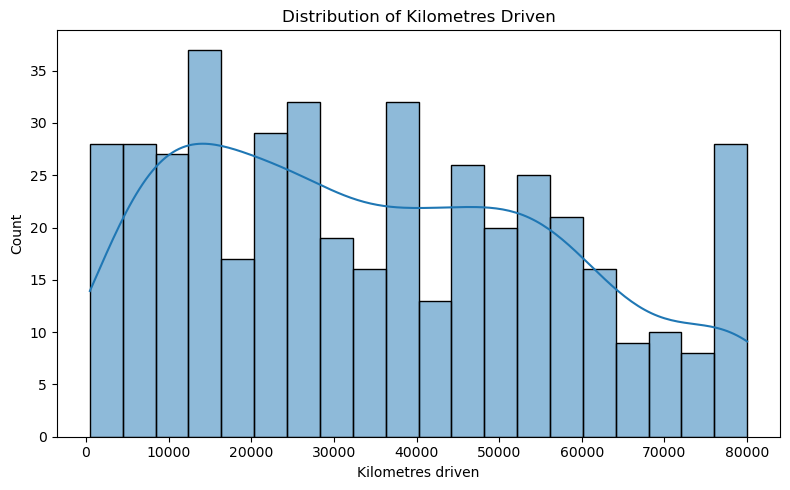

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='km_driven', bins=20, kde=True)
plt.title('Distribution of Kilometres Driven')
plt.xlabel('Kilometres driven')
plt.tight_layout()
plt.show()


**Q4.2 For every brand, show how many bikes were sold in the first week and how many were not, using `sns.countplot()` with `hue='sold_in_week'`.**

---



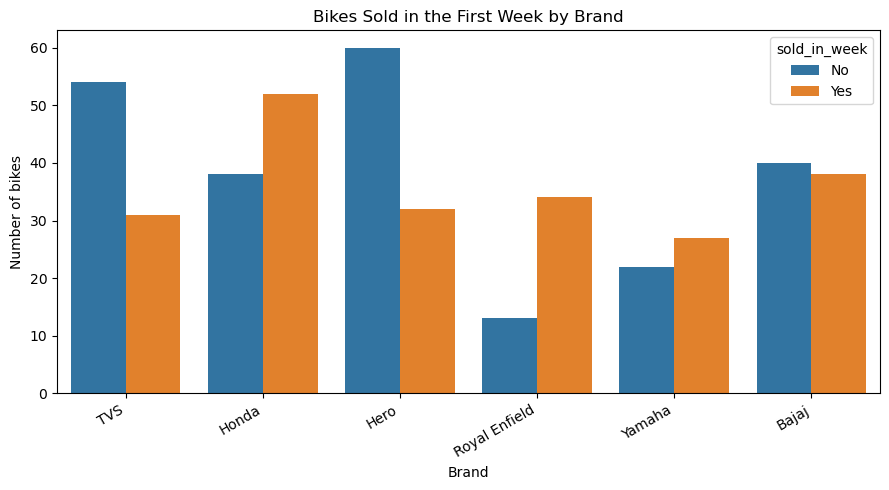

In [22]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='brand', hue='sold_in_week')
plt.title('Bikes Sold in the First Week by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of bikes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Q4.3 A buyer says condition does not change the price. Draw one plot of `price_thousand` for each `condition`.**

---



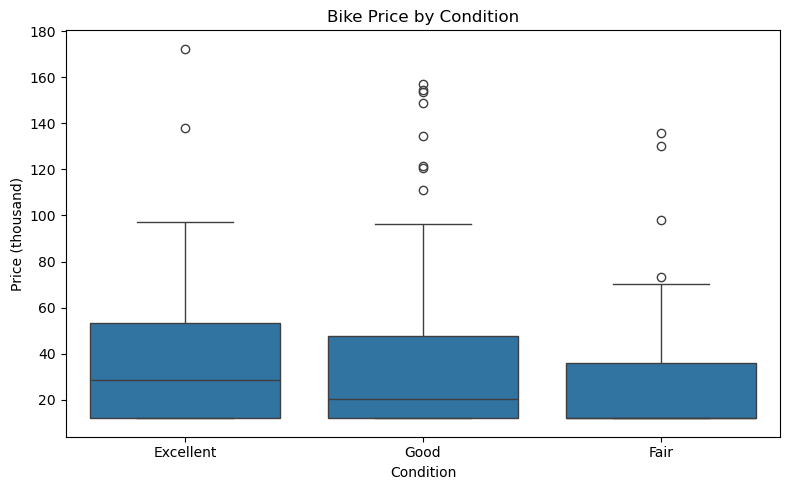

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='condition', y='price_thousand')
plt.title('Bike Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Price (thousand)')
plt.tight_layout()
plt.show()


**Q4.4 Looking at the plot above — is the buyer right or wrong? Write your answer as a comment.**

---



In [24]:
# The buyer is wrong: the price distributions differ by condition; better-condition bikes generally have higher prices.


**Q4.5 Draw `age_months` against `price_thousand`, coloured by `sold_in_week`.**

---



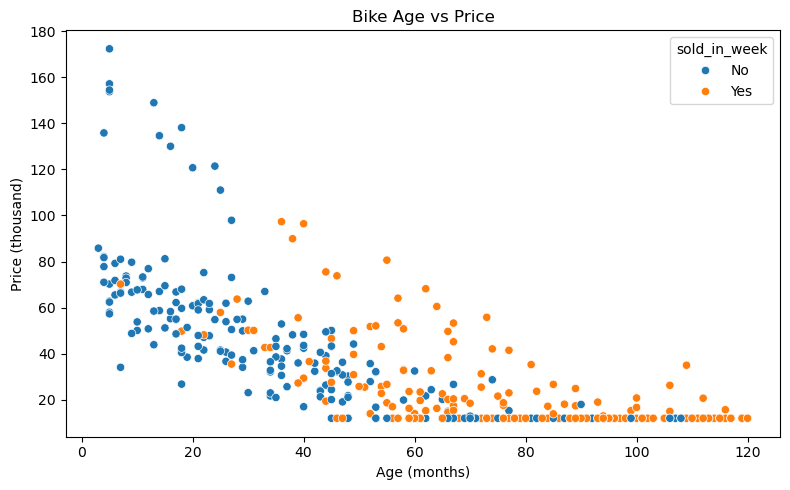

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age_months', y='price_thousand', hue='sold_in_week')
plt.title('Bike Age vs Price')
plt.xlabel('Age (months)')
plt.ylabel('Price (thousand)')
plt.tight_layout()
plt.show()


**Q4.6 Based on that scatter plot — what happens to price as a bike gets older? Write your answer as a comment.**

---



In [26]:
# Price generally decreases as a bike gets older.


**Q4.7 Draw a heatmap of the correlation between the numeric columns.**

---



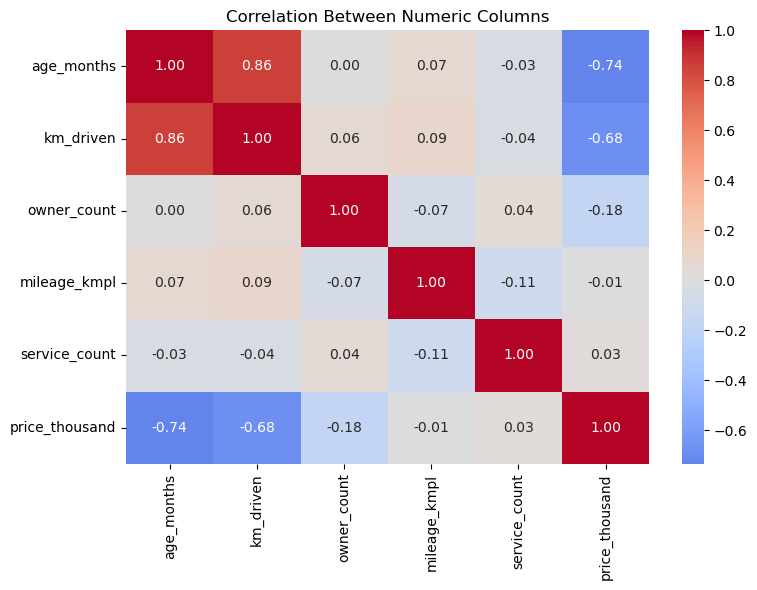

In [27]:
plt.figure(figsize=(8, 6))
numeric_corr = df.select_dtypes(include='number').corr()
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Numeric Columns')
plt.tight_layout()
plt.show()


**Q4.8 From the heatmap — which two columns move together the most? Write your answer as a comment.**

---



In [28]:
# `age_months` and `km_driven` move together the most: older bikes generally have been driven farther.
